# Volleyball Motion Tracking

## Rhys Pulling

DSCI 503 Project:

Extract data from a video of a volleyball game/play. The dataset is from the following github: https://github.com/shukkkur/VolleyVision/tree/main?tab=readme-ov-file. Then use the data to predict an outcome of the game (score pass, ace, who gets set, etc.).

## Data Collection and Preprocessing

The first step of the project is, of course, finding data and performing any preprocessing that is required. Due to the nature of my project, there will be two parts to preprocessing:
1. Collection and preprocessing of related videos/images
2. Preprocessing of data collected from feature extraction of the videos

I am currently working on part one.

### Collection and Preprocessing of Videos

As mentioned earlier, the data I plan on using I found through the VolleyVision github repository by Shukkur. They have listed various datasets used for different steps in their training filled with thousands of images, so it seems best to utilize these datasets.

The first dataset I downloaded was: [Volleyball_v2 Dataset](https://universe.roboflow.com/shukur-sabzaliev1/volleyball_v2/dataset/2). The format used was yolov8. It is a huge dataset so I stored the file on google drive and will mount my google drive so it doesn't have to be downloaded every time.

In [ ]:
from google.colab import drive
from PIL import Image

# Mount Google Drive for fast, responsible access to files
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import os

# find path and then change directory
# volleypath = '/content/gdrive/MyDrive/College/Mines/DSCI 503/'
# os.chdir(volleypath)

In [ ]:
# unzip the zip file
# runs for awhile, so only run at start of a session
!unzip "/content/gdrive/MyDrive/College/Mines/DSCI 503/Volleyball_v2.v2-640x640.yolov8.zip" -d "/content/Volleyball_v2.v2-640x640.yolov8" # unlabeled images
# !unzip "/content/gdrive/MyDrive/College/Mines/DSCI 503/Volleyball Actions.v5-original.yolov8.zip" -d "/content/Volleyball Actions.v5-original.yolov8" # labeled action images

Streaming output truncated to the last 5000 lines.
 extracting: /content/Volleyball_v2.v2-640x640.yolov8/train/labels/VID_20200914_223523-017_jpg.rf.202d90172bf1ee57b85581124e1549db.txt  
 extracting: /content/Volleyball_v2.v2-640x640.yolov8/train/labels/VID_20200914_223523-017_jpg.rf.252e16ded10eb766752a3ca9aeb0aee8.txt  
 extracting: /content/Volleyball_v2.v2-640x640.yolov8/train/labels/VID_20200914_223523-017_jpg.rf.5fd74fff8d8c35005d71c451196d5fd9.txt  
 extracting: /content/Volleyball_v2.v2-640x640.yolov8/train/labels/VID_20200914_223523-018_jpg.rf.337b2d98d1c8dda0512e01262c3cb19f.txt  
 extracting: /content/Volleyball_v2.v2-640x640.yolov8/train/labels/VID_20200914_223523-018_jpg.rf.5d8895bc6ca6cfd45cff5e77b00bdbef.txt  
 extracting: /content/Volleyball_v2.v2-640x640.yolov8/train/labels/VID_20200914_223523-018_jpg.rf.734cd2d67f39f4ca3039a17eab1c9cfc.txt  
 extracting: /content/Volleyball_v2.v2-640x640.yolov8/train/labels/VID_20200914_223523-019_jpg.rf.5733f085065fa906fe385c17c6cd9

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

It is already stored with a train, val, and test split so this step of preprocessing does not need to be done here.

In [ ]:
from glob import glob

# unlabeled images
train_images = glob('/content/Volleyball_v2.v2-640x640.yolov8/train/images/*.jpg')
val_images = glob('/content/Volleyball_v2.v2-640x640.yolov8/valid/images/*.jpg')
test_images = glob('/content/Volleyball_v2.v2-640x640.yolov8/test/images/*.jpg')

# labeled action images
# train_images = glob('/content/Volleyball Actions.v5-original.yolov8/train/images/*.jpg')
# val_images = glob('/content/Volleyball Actions.v5-original.yolov8/valid/images/*.jpg')
# test_images = glob('/content/Volleyball Actions.v5-original.yolov8/test/images/*.jpg')
# train_labels = glob('/content/Volleyball Actions.v5-original.yolov8/train/labels/*.txt')
# val_labels = glob('/content/Volleyball Actions.v5-original.yolov8/valid/labels/*.txt')
# test_labels = glob('/content/Volleyball Actions.v5-original.yolov8/test/labels/*.txt')

len(train_images), len(val_images), len(test_images) # , len(train_labels), len(val_labels), len(test_labels)

(15184, 1898, 1898)

In [ ]:
# import random

# n_subset = 2500
# train_images = random.sample(train_images, n_subset)
# len(train_images)

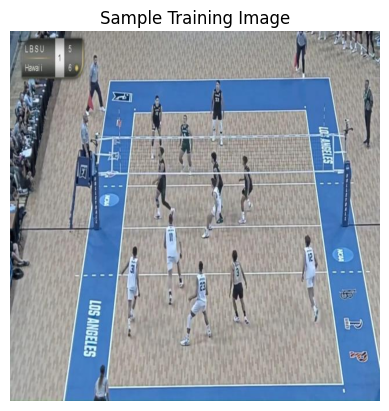

In [ ]:
import matplotlib.pyplot as plt
import cv2

# Display a sample training image
sample_image_path = train_images[5]
image = cv2.imread(sample_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title('Sample Training Image')
plt.axis('off')
plt.show()

There are different kinds of preprocessing we can do for computer vision, and just for image data in general:
* Resize Images
* Normalization
* Data Augmentation
* Label Encoding
* Examing / Handling Imbalance

In [ ]:
# # Function to resize and normalize images
def process_images(image_paths, image_size=(640, 640)):
    cleaned_images = []

    for i, image_path in enumerate(image_paths):
        image = cv2.imread(image_path)

        # Check if the image was loaded successfully
        if image is not None:
            try:
                # Resize the image
                resized_image = cv2.resize(image, image_size)
                # Normalize and append to the list
                normalized_image = resized_image.astype("float32") / 255.0
                cleaned_images.append(normalized_image)
            except Exception as e:
                print(f"Error processing image {image_path}: {e}")
        else:
            print(f"Error loading image: {image_path}")

    return np.array(cleaned_images)

# Process the train, validation, and test images
cleaned_train_images = process_images(train_images[:1000], (320, 320))
cleaned_val_images = process_images(val_images[:334], (320, 320))
cleaned_test_images = process_images(test_images[:334], (320, 320))

In [ ]:
np.array(cleaned_train_images).shape, np.array(cleaned_val_images).shape, np.array(cleaned_test_images).shape

((1000, 320, 320, 3), (334, 320, 320, 3), (334, 320, 320, 3))

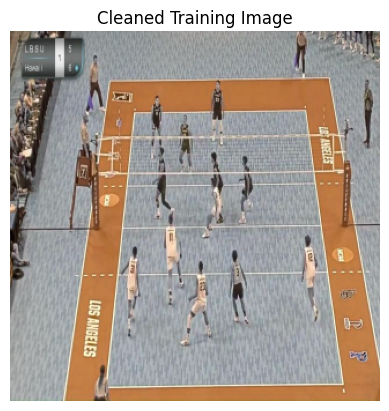

In [ ]:
# Display the preprocessed sample image
image = cleaned_train_images[5] # cleaned_train_images already contains image data
plt.imshow(image)
plt.title('Cleaned Training Image')
plt.axis('off')
plt.show()

### Exploratory Data Analysis

Some ways to do EDA on unlabeled image data are:
- Color channel analysis
- Pixel intensity distribution
- Image sampling

In [ ]:
# image sampling
# just looking at a random sample of images
# random_indices = np.random.choice(len(cleaned_train_images), size=5, replace=False)
# sampled_images = [cleaned_train_images[i] for i in random_indices]

# fig, axes = plt.subplots(1, 5, figsize=(15, 3))
# for i, ax in enumerate(axes):
#     ax.imshow(sampled_images[i])
#     ax.axis('off')
# plt.show()

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Number of images to analyze
# num_images = 5

# # Create subplots for each image
# fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))

# # Iterate through selected images
# for i in range(num_images):
#     # Load the image
#     image = cleaned_train_images[i]  # Select the image for analysis

#     # Convert image data to a numpy array in the expected format for PIL
#     image = Image.fromarray((image * 255).astype(np.uint8))

#     # Convert image data to a numpy array
#     image_data = np.array(image)

#     # Flatten the array to get a list of pixels
#     pixels = image_data.reshape(-1, 3)

#     # Separate RGB channels
#     red_values = pixels[:, 0]
#     green_values = pixels[:, 1]
#     blue_values = pixels[:, 2]

#     # Plot histograms for each color channel
#     axes[i, 0].hist(red_values, bins=256, color='red', alpha=0.6)
#     axes[i, 0].set_title(f"Red Channel - Image {i+1}")

#     axes[i, 1].hist(green_values, bins=256, color='green', alpha=0.6)
#     axes[i, 1].set_title(f"Green Channel - Image {i+1}")

#     axes[i, 2].hist(blue_values, bins=256, color='blue', alpha=0.6)
#     axes[i, 2].set_title(f"Blue Channel - Image {i+1}")

# plt.tight_layout()
# plt.show()

In [ ]:
# image sampling
# just looking at a random sample of images
# sampled_images = cleaned_train_images[:5]

# # convert back to color
# color_images = []
# for i in range(5):
#     # Load the image
#     image = sampled_images[i]  # Select the image for analysis

#     # Convert image data to a numpy array in the expected format for PIL
#     image = Image.fromarray((image * 255).astype(np.uint8))

#     color_images.append(image)

# fig, axes = plt.subplots(1, 5, figsize=(15, 3))
# for i, ax in enumerate(axes):
#     ax.imshow(color_images[i])
#     ax.axis('off')
# plt.show()

In [ ]:
# pixel intensity distribution
# histogram of pixel intensities
# pixel_intensities = cleaned_train_images[:5].flatten()
# plt.hist(pixel_intensities, bins=256, color='gray', alpha=0.7)

## Object Detection

Now that we have a preprocessed dataset we can begin trying to train a model to detect volleyballs within the image. The dataset was downloaded as Volov8 text file, so we can try using the Volov8 model to perform this.

It seems like I can use CV2 to help with object recognition.
- Contour can be used for finding shapes, I just need to find the color range of volleyballs

In [ ]:
# Load the image
# img = cleaned_train_images[5]
# img = (img * 255).astype(np.uint8)

# # Apply Canny edge detector
# edges = cv2.Canny(img, 100, 200)

# # Find contours from the edges
# contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# # Draw contours on the original image
# img_contours = img.copy()
# cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)

# # display image
# plt.imshow(cleaned_train_images[5])
# plt.title('Cleaned Training Image')
# plt.axis('off')
# plt.show()

In [ ]:
!pip install mediapipe opencv-python-headless scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.1/36.1 MB 21.0 MB/s eta 0:00:00


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Initialize MediaPipe Pose Estimation
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
pose = mp_pose.Pose()

In [ ]:
def extract_features(image_path):
    # Load the image
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Run pose detection
    results = pose.process(image_rgb)
    features = []

    # If players are detected
    if results.pose_landmarks:
        # Extract relevant landmarks, e.g., for hands and body
        landmarks = results.pose_landmarks.landmark

        # Calculate example features
        # Example: Right hand position
        right_hand = landmarks[mp_pose.PoseLandmark.RIGHT_WRIST]
        right_hand_x, right_hand_y = right_hand.x, right_hand.y

        # Example: Torso center position (as a proxy for player position)
        left_shoulder = landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER]
        right_shoulder = landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER]
        torso_x = (left_shoulder.x + right_shoulder.x) / 2
        torso_y = (left_shoulder.y + right_shoulder.y) / 2

        # Append positional data to features list
        features.extend([right_hand_x, right_hand_y, torso_x, torso_y])

        # Additional features can be added here (e.g., distances between players, body orientation)

    return features

In [ ]:
# unlabeled data w/ mediapipe
# Collect features from each image
X = []
for image_path in train_images[:1000]:
    features = extract_features(image_path)
    if features:
        X.append(features)

X = np.array(X)
print(X.shape)

(337, 4)


In [ ]:
# Split data into train and test sets
X_train, X_test = X[:275], X[275:]

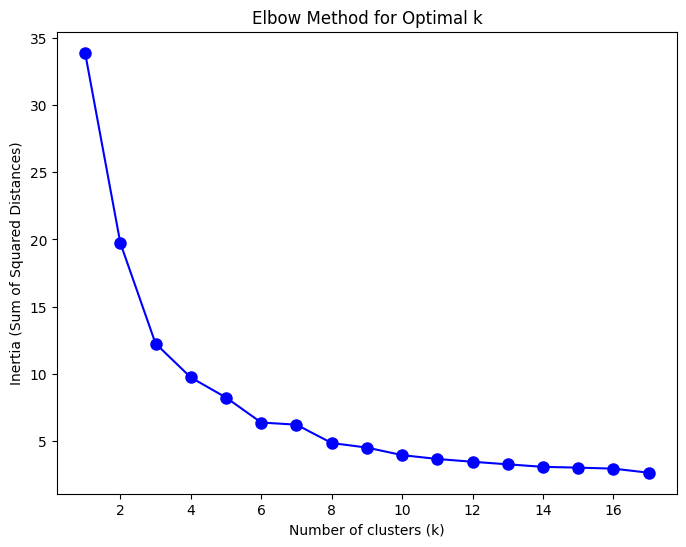

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Define the range of k values to try
k_values = range(1, 18)

# List to store the inertia values for each k
inertia_values = []

# Run KMeans with each k and store the inertia
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train)
    inertia_values.append(kmeans.inertia_)

# Plot the results
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia_values, 'bo-', markersize=8)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal k')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

y_pred = kmeans.predict(X)
silhouette_avg = silhouette_score(X, y_pred)
print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.3835866467991643


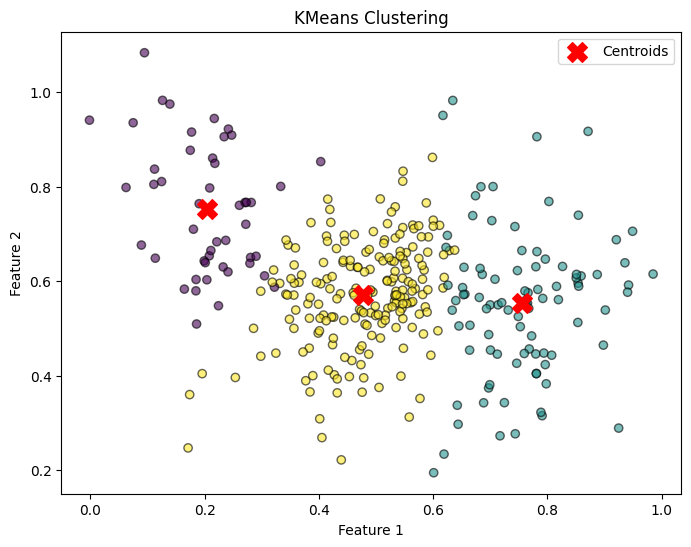

In [ ]:
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Plotting
plt.figure(figsize=(8, 6))
# Accessing columns within the bounds of X (0 to 3)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o', edgecolor='k', alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.title('KMeans Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

### Volo V8

The below code is in case I end up needing to use a pretrained Volo model.

In [ ]:
!pip install ultralytics

  Using cached ultralytics-8.3.34-py3-none-any.whl.metadata (35 kB)
  Using cached ultralytics_thop-2.0.12-py3-none-any.whl.metadata (9.4 kB)
Using cached ultralytics-8.3.34-py3-none-any.whl (887 kB)
Using cached ultralytics_thop-2.0.12-py3-none-any.whl (26 kB)


In [ ]:
# with open('/content/Volleyball Actions.v5-original.yolov8/data.yaml', 'r') as f:
#     print(f.read())

In [ ]:
# need to make a .yaml file with the information about the cleaned images

# Set the path to your dataset
# dataset_path = '/content/content/cleaned_images'

# # Create the YAML content
# data_yaml = f"""
# train: {dataset_path}/train/images
# val: {dataset_path}/val/images
# test: {dataset_path}/test/images

# nc: 5
# names: ['block', 'defense', 'serve', 'set', 'spike']
# """

# # Write the content to the data.yaml file
# with open('/content/content/cleaned_images/data.yaml', 'w') as f:
#     f.write(data_yaml)

# print("data.yaml file created successfully!")

In [ ]:
# with open('/content/content/cleaned_images/data.yaml', 'r') as f:
#     print(f.read())

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

# # Train the model
# model.train(
#     data='/content/content/cleaned_images/data.yaml',
#     epochs=50,
#     batch=16,
#     imgsz=640
# )

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 40.7MB/s]


In [ ]:
# copied model after training
# !cp -r "./runs/detect/train/weights" "/content/gdrive/MyDrive/College/Mines/DSCI 503/yolov8_model"

# get model back
# Load the model from Google Drive
# model = YOLO('/content/gdrive/MyDrive/College/Mines/DSCI 503/yolov8_model/best.pt') # only 31 epochs were done

In [ ]:
import cv2
import numpy as np
import os

# Directory of images
image_dir = '/content/Volleyball_v2.v2-640x640.yolov8/train/images'
image_files = train_images[:1000]

# image_dir = '/content/content/cleaned_images/train/images'
# image_files = cleaned_train_images[:1000]

# extract information from the images using
X = []
for image_path in image_files:
    #image_path = os.path.join(image_dir, image_file)
    image = cv2.imread(image_path)

    results = model(image)
    for result in results:
        detections = result.boxes

        # Initialize feature vector for this image
        image_features = []
        for det in detections:
            # Get class, confidence, and bounding box coordinates
            class_id = int(det.cls.item())
            confidence = float(det.conf.item())
            x_center = float(det.xywh[0, 0].item())
            y_center = float(det.xywh[0, 1].item())
            width = float(det.xywh[0, 2].item())
            height = float(det.xywh[0, 3].item())

            # Optionally, only select relevant classes (e.g., players)
            # if class_id not in [0, 1]:  # Example class filter
            #     continue

            # Combine all features into a single vector
            object_features = [class_id, confidence, x_center, y_center, width, height]
            image_features.extend(object_features)  # Aggregate all objects in the image

        # Append image features to the feature matrix
        X.append(image_features)


0: 640x640 11 persons, 739.1ms
Speed: 7.5ms preprocess, 739.1ms inference, 50.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 9 persons, 579.6ms
Speed: 3.1ms preprocess, 579.6ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 14 persons, 526.8ms
Speed: 3.6ms preprocess, 526.8ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 17 persons, 448.0ms
Speed: 3.6ms preprocess, 448.0ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 5 persons, 503.3ms
Speed: 5.1ms preprocess, 503.3ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 7 persons, 1 bird, 529.5ms
Speed: 5.6ms preprocess, 529.5ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 9 persons, 1 horse, 482.1ms
Speed: 7.1ms preprocess, 482.1ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 14 persons, 442.2ms
Speed: 4.7ms preprocess, 442.2ms inference, 

In [ ]:
# Preprocess extracted data for the below algorithms
from sklearn.preprocessing import StandardScaler

# labeled data w/ Yolov8
# Define max number of detections per image
max_detections = 1

# Prepare a fixed-length feature array
X_fixed = []

for features in X:
    # Limit to top 3 detections (or pad with zeros if fewer)
    detections = np.array(features).reshape(-1, 6)  # Each detection has 6 features
    detections = detections[:max_detections]        # Limit to top 3 detections
    while len(detections) < max_detections:
        detections = np.vstack([detections, np.zeros(6)])  # Pad with zeros
    X_fixed.append(detections.flatten())  # Flatten to single row

X_fixed = np.array(X_fixed)

# Optionally, normalize features
scaler = StandardScaler()
X_fixed = scaler.fit_transform(X_fixed)
print(X_fixed.shape)

(1000, 6)


In [ ]:
# labels_dir = '/content/content/cleaned_images/train/labels'
# label_paths = cleaned_train_labels[:1000]
# label_paths = train_labels[:1000]

# y = []
# for label_file in label_paths:
#     if label_file.endswith('.txt'):
#         # Path to the label file
#         # label_path = os.path.join(labels_dir, label_file)
#         label_path = label_file

#         # Read the label file and extract class IDs
#         with open(label_path, 'r') as file:
#             class_ids = [int(line.split()[0]) for line in file.readlines()]
#             y.append(class_ids[0] if class_ids else -1)  # Add all class IDs to the y list

# y = np.array(y)
# print(y.shape)

In [ ]:
# Split data into train and test sets
X_train, X_test = X_fixed[:750], X_fixed[750:]

### SVM Model

### KMeans

We don't have actually labeled image data, so it makes sense to cluster the extracted information together and use silhouette score to see how strong the clustering is.

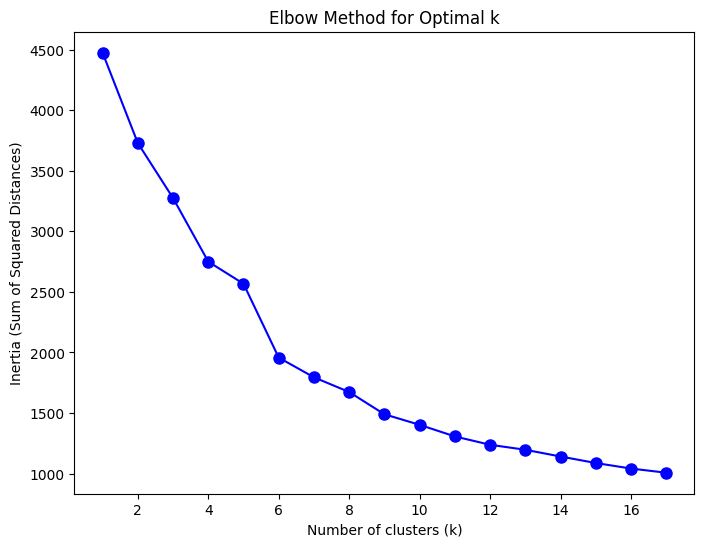

In [ ]:
# Define the range of k values to try
k_values = range(1, 18)

# List to store the inertia values for each k
inertia_values = []

# Run KMeans with each k and store the inertia
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train)
    inertia_values.append(kmeans.inertia_)

# Plot the results
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia_values, 'bo-', markersize=8)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal k')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=6)
kmeans.fit(X_train)

y_pred = kmeans.predict(X_test)
silhouette_avg = silhouette_score(X_test, y_pred)
print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.21929295991708656


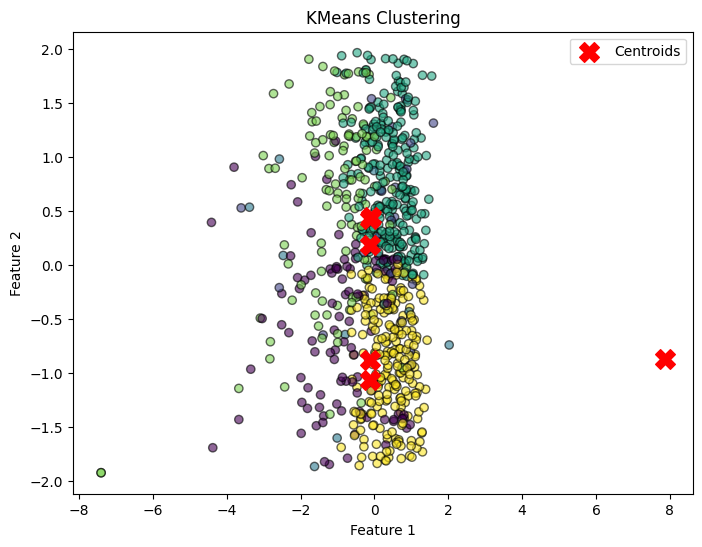

In [ ]:
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Plotting
plt.figure(figsize=(8, 6))
# Access the first two columns of X_train for plotting
plt.scatter(X_train[:, 1], X_train[:, 2], c=labels, cmap='viridis', marker='o', edgecolor='k', alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.title('KMeans Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()